# Compare market production methods (savegame)

Loads **format-2** `.pkl` snapshots from `analysis/savegame/notebooks/save_game_temp` (same pipeline as `compare_savegames_market.ipynb`): `locations` (already merged with region hierarchy), `buildings` (production methods per building), `market_goods`, etc.

**Recipe weights and PM slot groups** (food / drinks / packaging) are loaded from **`game_path` / `mod_path`** in your config via `BuildingData`—the same definitions as `production_method_comparison.ipynb`. Snapshots only store *which* PM each building uses; they do not embed recipe quantities.

Filters to one building type (default **`cookery`**, e.g. Prosper or Perish). Use `first_savegame` / `last_savegame` to slice snapshots (`last_savegame = 1` with `first_savegame = 0` for a single file).

**Global resource usage:** for the **latest** snapshot, three tables (**food** / **drinks** / **packaging**) list each trade **good** and **total_input** = sum over all cookery buildings of (recipe input parsed from `building_types` × buildings using that PM). PMs with no goods (e.g. well water, no packaging) contribute no rows. Locations are merged with **`LocationData`** (`merge_saves_with_location_data`) so **`macro_region`** is available; one column per macro region (slug as column name, same units as `total_input`), ordered by **descending column total** within that category so the largest regional footprints appear first. Missing macro region is bucketed as **`__unknown`**. Each table also includes **base_cost** (game `default_market_price` from merged goods definitions) and **total_cost** = `total_input` × `base_cost`.

**Global PM table:** counts how many cookery buildings use each `pp_cookery_*` method in the **latest** loaded snapshot (so totals are not multiplied when you load many time slices). Rows are grouped into **food**, **drinks**, and **packaging** to match the three `unique_production_methods` slots in the Prosper or Perish cookery building.

**Regional PM preferences:** three wide tables (`regional_prefs_food` / `regional_prefs_drinks` / `regional_prefs_packaging`) give, for each **macro region**, the **percentage share** of each production method in that slot as **whole-number** percentages (rows sum to ~100% per region); column names drop the `pp_cookery_` prefix for readability. PM columns are ordered by global usage in that slot (most common first).

**Regional spend mix:** three wide tables (`regional_spend_share_food` / `regional_spend_share_drinks` / `regional_spend_share_packaging`) show, for each **macro region**, the **percentage** of **base-price** cookery input spend (recipe quantity × `default_market_price` per trade good) allocated to each **good** in that slot; rows match regional PM ordering, good columns by descending global spend in that slot.

**Time-series plots:** when you load **multiple** snapshots, three line charts show how many buildings globally use each production method in the food, drink, and packaging slots over time (one line per `pp_cookery_*` method in that slot). The horizontal axis matches **`compare_savegames.ipynb`**: snapshot index 0, 1, … is labeled as **game years** (`start_year` 1337 + index × `years_per_snapshot` 5).

Pkls must include a **`buildings`** key (re-run the savegame watcher / processor with current ProsperPerishCalcs if yours were produced before that field existed).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from IPython.display import display

from core.parser.path_resolver import PathResolver
from core.data.building_data import BuildingData
from core.data.goods_data import GoodsData
from analysis.building_levels.building_analysis import load_config
from analysis.savegame import (
    buildings_df_from_pkl,
    locations_df_from_pkl,
    resolve_pkl_dir,
)
from analysis.savegame.datalocations import merge_saves_with_location_data

pd.options.display.max_columns = None
pd.options.display.width = 200

In [2]:
# Cookery: three UPM slots from parsed mod `building_types` (same source as production_method_comparison)
config = load_config()
path_resolver = PathResolver(config["game_path"], config["mod_path"])
building_data = BuildingData(path_resolver)
building_data.load_all()

goods_data = GoodsData(path_resolver)
goods_data.load_all()

cookery_maps = building_data.cookery_pm_maps("cookery")

_COOKERY_PM_FOOD = cookery_maps.food
_COOKERY_PM_DRINKS = cookery_maps.drinks
_COOKERY_PM_PACKAGING = cookery_maps.packaging
_COOKERY_PM_GOOD_INPUTS = cookery_maps.pm_good_inputs


def _cookery_pm_category(pm: str) -> str:
    return cookery_maps.category(pm)


In [3]:
"""Load .pkl snapshots (format-2 with market_goods + buildings)."""

# None = auto (newest playthrough under save_game_temp), or set path to your playthrough folder
PKL_PATH = None  # e.g. ".../save_game_temp/<playthrough_id>"
first_savegame = 0
last_savegame = None  # None = all; use 1 with first_savegame=0 for one snapshot only

pkl_dir = resolve_pkl_dir(PKL_PATH)
pkl_files = sorted(pkl_dir.glob("*.pkl"), key=lambda p: p.stem)
if last_savegame is not None:
    pkl_files = pkl_files[first_savegame:last_savegame]
else:
    pkl_files = pkl_files[first_savegame:]

raw = {p.stem: pd.read_pickle(p) for p in pkl_files}

for label, payload in raw.items():
    if not isinstance(payload, dict) or "market_goods" not in payload:
        raise TypeError(
            f"{label}: expected format-2 pkl with 'market_goods'. Got {type(payload).__name__}"
        )
    if "buildings" not in payload:
        raise ValueError(
            f"{label}: pkl has no 'buildings' key. Regenerate snapshots with the current "
            "savegame processor / watcher (format-2 now includes buildings)."
        )

_locations_merged = merge_saves_with_location_data(raw)

n_snap = len(raw)
print(f"Loaded {n_snap} snapshot(s) from {pkl_dir}")
print(f"Labels: {list(raw.keys())}")

Loaded 102 snapshot(s) from C:\Development\ProsperPerishCalcs\analysis\savegame\notebooks\save_game_temp\5cc58dda_a771_4ccd_b17d_1f88b360b2a9
Labels: ['20260325_160944', '20260325_161108', '20260325_161229', '20260325_161356', '20260325_161522', '20260325_161643', '20260325_161803', '20260325_161920', '20260325_162037', '20260325_162156', '20260325_162318', '20260325_162434', '20260325_162550', '20260325_162709', '20260325_162835', '20260325_162957', '20260325_163117', '20260325_163237', '20260325_163355', '20260325_163513', '20260325_163629', '20260325_163745', '20260325_163901', '20260325_164016', '20260325_164129', '20260325_164239', '20260325_164351', '20260325_164503', '20260325_164615', '20260325_164729', '20260325_164842', '20260325_164953', '20260325_165119', '20260325_165216', '20260325_165328', '20260325_165442', '20260325_165553', '20260325_165706', '20260325_165817', '20260325_165929', '20260325_170045', '20260325_170159', '20260325_170313', '20260325_170428', '20260325_170

In [4]:
# Building type to analyze (Prosper or Perish cookery); set to None to include all building types
BUILDING_SLUG = "cookery"

parts = []
for label, payload in raw.items():
    b = buildings_df_from_pkl(payload)
    if BUILDING_SLUG and "slug" in b.columns:
        b = b[b["slug"] == BUILDING_SLUG].copy()
    b["snapshot"] = label
    loc = _locations_merged.get(label)
    if not isinstance(loc, pd.DataFrame) or "location_id" not in loc.columns:
        loc = locations_df_from_pkl(payload)
    if "macro_region" not in loc.columns:
        for alias in ("macro_region_loc", "macro_region_pkl"):
            if alias in loc.columns:
                loc = loc.copy()
                loc["macro_region"] = loc[alias]
                break
    scope = [c for c in ("region", "macro_region", "super_region") if c in loc.columns]
    if "location_id" not in loc.columns or not scope:
        raise ValueError(f"{label}: locations frame missing location_id or scope columns.")
    # Omit location `slug` so it does not collide with building `slug`
    loc_sub = loc[["location_id", *scope]].drop_duplicates(subset=["location_id"])
    merged = b.merge(loc_sub, on="location_id", how="left", suffixes=("", "_loc"))
    parts.append(merged)

enriched = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
# if not enriched.empty:
#     display(enriched.head(20))
# else:
#     slug_msg = f"slug={BUILDING_SLUG!r}" if BUILDING_SLUG else "all slugs"
#     print(f"No matching buildings ({slug_msg}) in selected snapshot(s).")

In [5]:
# Global PM table (latest snapshot only)
if enriched.empty:
    pm_global = pd.DataFrame()
    print("No data for global PM counts.")
else:
    # Latest snapshot only: one world state, not N × duplicate buildings across time slices
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base = enriched[enriched["snapshot"] == _last_snap]
        print(f"Global PM counts use snapshot: {_last_snap}")
    else:
        _base = enriched

    pm_long = _base.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    pm_long = pm_long[pm_long["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    counts = pm_long["production_method"].value_counts()
    pm_global = counts.rename("building_uses").reset_index()
    pm_global.columns = ["production_method", "building_uses"]
    pm_global["category"] = pm_global["production_method"].map(_cookery_pm_category)
    _cat_order = {"food": 0, "drinks": 1, "packaging": 2, "other": 3}
    pm_global["_k"] = pm_global["category"].map(_cat_order)
    pm_global = (
        pm_global.sort_values(["_k", "building_uses", "production_method"], ascending=[True, False, True])
        .drop(columns=["_k"])
        .reset_index(drop=True)
    )
    display(pm_global)
    cat_totals = (
        pm_global.groupby("category", sort=False)["building_uses"]
        .sum()
        .reindex(["food", "drinks", "packaging", "other"], fill_value=0)
        .rename("sum_building_uses")
        .to_frame()
    )
    display(cat_totals)

Global PM counts use snapshot: 20260325_183001


,production_method,building_uses,category
0,pp_cookery_labskaus,715,food
1,pp_cookery_ika_mata,514,food
2,pp_cookery_pemmican,310,food
3,pp_cookery_fish_congee,289,food
4,pp_cookery_mutton_and_pease,284,food
5,pp_cookery_livestock_pottage,257,food
6,pp_cookery_mediterranean_fish,246,food
7,pp_cookery_pozole,225,food
8,pp_cookery_khichdi,151,food
9,pp_cookery_saltfish_porridge,117,food


,sum_building_uses
category,
food,3501
drinks,3501
packaging,3501
other,0


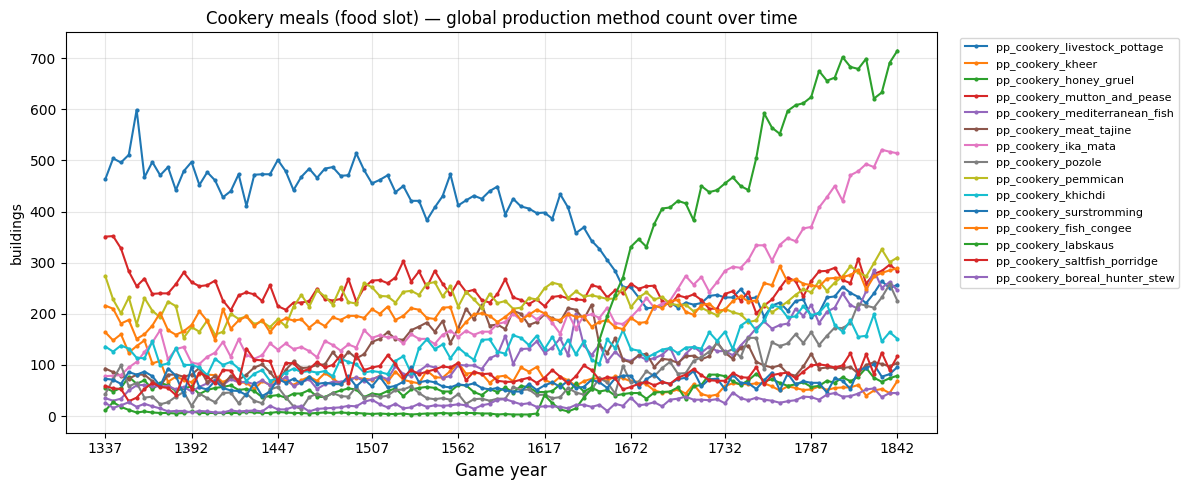

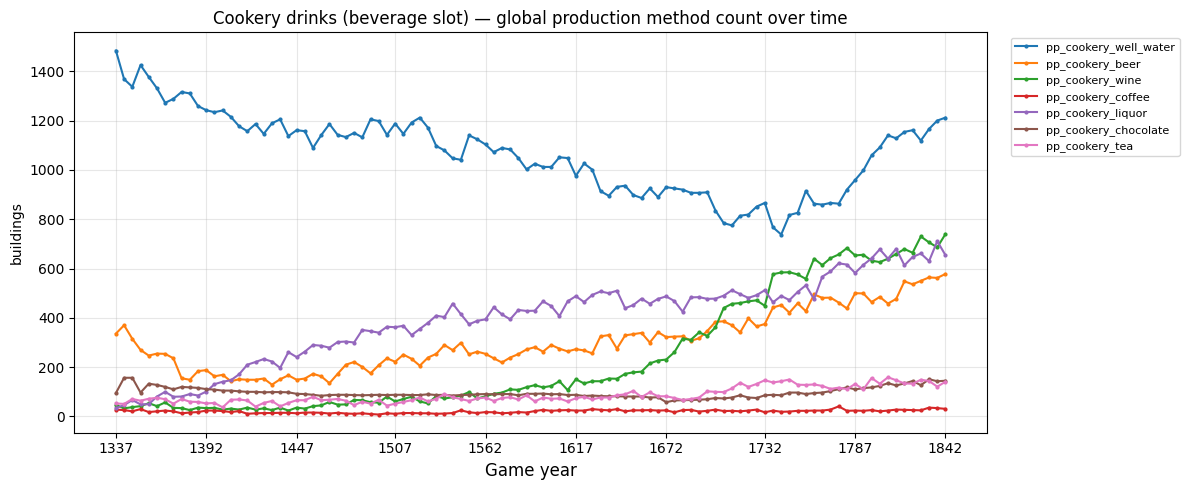

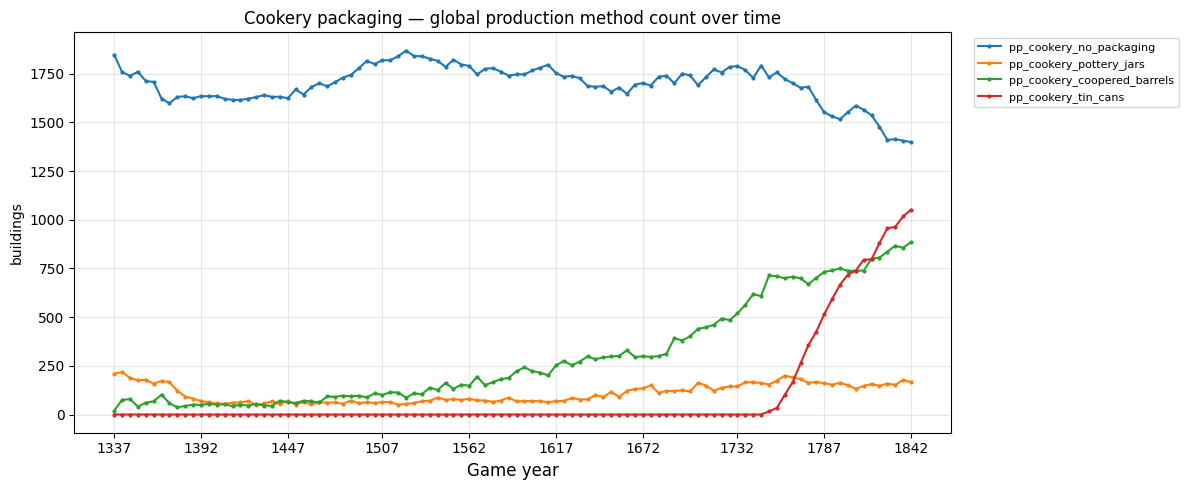

In [6]:
# Time series: global cookery PM counts per snapshot (meals / drinks / packaging slots)
if enriched.empty or "snapshot" not in enriched.columns:
    print("No time-series data (need non-empty enriched with snapshot).")
else:
    pm_ts = enriched.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    pm_ts = pm_ts[pm_ts["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    pm_ts["category"] = pm_ts["production_method"].map(_cookery_pm_category)
    pm_ts = pm_ts[pm_ts["category"] != "other"]
    if pm_ts.empty:
        print("No pp_cookery_* production methods to plot.")
    else:
        counts = (
            pm_ts.groupby(["snapshot", "category", "production_method"], sort=False)
            .size()
            .rename("n")
        )
        snap_order = sorted(enriched["snapshot"].astype(str).unique())
        # X-axis: same convention as compare_savegames.ipynb (snapshot index -> game year)
        years_per_snapshot = 5
        start_year = 1337  # EU5 start
        n_ticks = 10
        n = len(snap_order)
        x_pos = list(range(n))
        if n <= 1:
            tick_positions = list(range(n))
        elif n <= n_ticks:
            tick_positions = list(range(n))
        else:
            step = (n - 1) / (n_ticks - 1)
            tick_positions = [int(round(i * step)) for i in range(n_ticks)]
        tick_labels = [start_year + pos * years_per_snapshot for pos in tick_positions]

        _slot_titles = {
            "food": "Cookery meals (food slot) — global production method count over time",
            "drinks": "Cookery drinks (beverage slot) — global production method count over time",
            "packaging": "Cookery packaging — global production method count over time",
        }
        for cat in ("food", "drinks", "packaging"):
            try:
                sub = counts.xs(cat, level="category")
            except KeyError:
                print(f"Skip time-series plot: no rows for category {cat!r}.")
                continue
            wide = sub.unstack(level="production_method", fill_value=0)
            wide = wide.reindex(snap_order).fillna(0).astype(int)
            if wide.empty:
                print(f"Skip time-series plot: empty pivot for {cat!r}.")
                continue
            fig, ax = plt.subplots(figsize=(12, 5))
            for col in wide.columns:
                ax.plot(x_pos, wide[col].values, label=col, marker="o", markersize=2)
            ax.set_title(_slot_titles[cat])
            ax.set_ylabel("buildings")
            ax.set_xlabel("Game year", fontsize=12)
            ax.tick_params(axis="both", labelsize=10)
            ax.grid(True, axis="both", alpha=0.3, linestyle="-")
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
            fig.tight_layout()
            plt.show()

In [7]:
# Global trade-good input usage (latest snapshot), by slot category — recipe inputs from
# Parsed per-PM trade-good inputs (_COOKERY_PM_GOOD_INPUTS) × count of cookery buildings using each PM.
if enriched.empty:
    print("No data for global resource usage.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base = enriched[enriched["snapshot"] == _last_snap]
        print(f"Global resource usage — snapshot {_last_snap}")
    else:
        _base = enriched
    ex = _base.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex = ex[ex["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if ex.empty:
        print("No pp_cookery_* production methods in this slice.")
    else:
        def _mr_col_suffix(mr):
            if pd.isna(mr):
                return "__unknown"
            return str(mr).strip().replace(" ", "_")

        pm_counts = ex["production_method"].value_counts()
        if "macro_region" in ex.columns:
            _mr_levels = sorted(
                {_mr_col_suffix(mr) for mr, _ in ex.groupby("macro_region", dropna=False)}
            )
        else:
            _mr_levels = []
            print(
                "No macro_region on building rows; omitting per-macro_region columns "
                "(use merged locations / pkls with hierarchy)."
            )
        for cat in ("food", "drinks", "packaging"):
            totals = defaultdict(float)
            for pm, n in pm_counts.items():
                if _cookery_pm_category(pm) != cat:
                    continue
                for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                    totals[good] += float(n) * float(qty)
            if not totals:
                print(f"\n{cat}: no trade-good inputs (empty recipe or no buildings).")
                continue
            totals_reg = defaultdict(lambda: defaultdict(float))
            if _mr_levels:
                for mr, ex_mr in ex.groupby("macro_region", dropna=False):
                    mk = _mr_col_suffix(mr)
                    pm_counts_mr = ex_mr["production_method"].value_counts()
                    for pm, n in pm_counts_mr.items():
                        if _cookery_pm_category(pm) != cat:
                            continue
                        for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                            totals_reg[good][mk] += float(n) * float(qty)
            df = pd.DataFrame(
                sorted(totals.items(), key=lambda kv: -kv[1]),
                columns=["good", "total_input"],
            )
            df["total_input"] = df["total_input"].round(2)
            df.insert(0, "category", cat)
            if _mr_levels:
                mr_cols = list(_mr_levels)
                for mrk in mr_cols:
                    df[mrk] = [
                        round(totals_reg[g].get(mrk, 0.0), 2) for g in df["good"]
                    ]
                _mr_order = df[mr_cols].sum().sort_values(ascending=False).index.tolist()
                df = df[["category", "good", "total_input", *_mr_order]]
            df["base_cost"] = df["good"].map(goods_data.modded_df["default_market_price"])
            df["total_cost"] = (df["total_input"] * df["base_cost"]).round(2)
            if _mr_levels:
                df = df[["category", "good", "total_input", "total_cost", "base_cost", *_mr_order]]
            else:
                df = df[["category", "good", "total_input", "total_cost", "base_cost"]]
            _missing = df.loc[df["base_cost"].isna(), "good"].tolist()
            if _missing:
                print(f"  Warning: no default_market_price in merged goods for: {_missing}")
            print(f"\n--- {cat} ---")
            display(df)

Global resource usage — snapshot 20260325_183001

--- food ---


,category,good,total_input,total_cost,base_cost,western_europe,east_asia,eastern_europe,south_asia,south_east_asia,middle_east,north_america,west_africa,east_africa,south_america,north_africa,central_africa,central_asia,southern_africa,pacific_islands,north_asia,south_atlantic_sub_continent
0,food,fish,6057.45,6057.45,1.00,1210.28,1127.80,642.43,556.13,815.08,253.36,345.40,239.38,189.14,242.69,246.01,124.42,8.74,31.91,20.0,0.00,4.68
1,food,livestock,3508.55,5262.83,1.50,961.73,766.32,644.19,292.13,44.82,248.60,33.74,150.07,110.07,54.08,34.32,55.32,97.94,11.98,0.0,3.24,0.00
2,food,wild_game,1980.00,1980.00,1.00,417.90,482.50,293.10,225.70,25.10,96.80,137.20,22.50,34.10,71.50,0.00,85.50,52.10,31.50,0.0,4.50,0.00
3,food,fruit,1887.01,1887.01,1.00,305.66,183.38,119.82,267.86,271.59,129.21,214.30,65.58,71.63,103.00,22.05,57.90,44.53,17.00,12.5,1.00,0.00
4,food,rice,1679.70,1679.70,1.00,6.60,881.10,23.10,204.60,188.10,82.50,3.30,151.80,62.70,9.90,23.10,13.20,9.90,19.80,0.0,0.00,0.00
5,food,legumes,1068.48,1068.48,1.00,298.36,361.51,107.69,52.14,22.48,104.31,6.17,37.57,6.50,12.34,27.73,4.93,26.10,0.00,0.0,0.65,0.00
6,food,wheat,1012.00,1012.00,1.00,192.00,196.80,163.20,113.60,2.40,101.60,0.00,84.80,48.80,0.00,21.60,16.00,68.00,0.00,0.0,3.20,0.00
7,food,wool,1008.20,1260.25,1.25,560.90,46.15,142.00,46.15,0.00,102.95,7.10,21.30,0.00,14.20,42.60,3.55,21.30,0.00,0.0,0.00,0.00
8,food,potato,672.10,672.10,1.00,258.50,156.04,153.22,21.62,7.52,24.44,3.76,12.22,10.34,13.16,7.52,3.76,0.00,0.00,0.0,0.00,0.00
9,food,maize,463.50,463.50,1.00,234.84,72.10,43.26,4.12,2.06,26.78,65.92,0.00,2.06,10.30,0.00,0.00,2.06,0.00,0.0,0.00,0.00



--- drinks ---


,category,good,total_input,total_cost,base_cost,western_europe,east_asia,eastern_europe,south_asia,middle_east,south_east_asia,west_africa,east_africa,north_america,north_africa,central_africa,south_america,central_asia,southern_africa,south_atlantic_sub_continent,pacific_islands,north_asia
0,drinks,wine,1554.00,3108.00,2.0,474.60,373.80,220.5,119.70,79.80,96.60,27.30,14.70,31.50,42.00,33.60,21.00,14.7,2.10,2.1,0.0,0.0
1,drinks,beer,1127.10,2254.20,2.0,382.20,241.80,117.0,134.55,81.90,35.10,39.00,27.30,5.85,37.05,1.95,5.85,15.6,1.95,0.0,0.0,0.0
2,drinks,liquor,1079.10,2697.75,2.5,328.35,140.25,59.4,100.65,103.95,122.10,77.55,37.95,9.90,21.45,33.00,16.50,19.8,8.25,0.0,0.0,0.0
3,drinks,tea,190.35,571.05,3.0,0.00,189.00,0.0,0.00,0.00,1.35,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0
4,drinks,cocoa,116.00,464.00,4.0,0.00,0.00,0.0,0.00,0.00,0.00,22.40,0.00,57.60,0.00,11.20,23.20,0.0,0.00,0.0,1.6,0.0
5,drinks,coffee,32.55,97.65,3.0,0.00,0.00,0.0,0.00,2.10,0.00,0.00,30.45,0.00,0.00,0.00,0.00,0.0,0.00,0.0,0.0,0.0



--- packaging ---


,category,good,total_input,total_cost,base_cost,western_europe,east_asia,eastern_europe,south_asia,south_east_asia,middle_east,west_africa,north_america,north_africa,south_america,central_africa,east_africa,southern_africa,central_asia,pacific_islands,north_asia,south_atlantic_sub_continent
0,packaging,steel,1051.0,5255.0,5.0,231.0,189.0,194.0,171.0,29.0,90.0,31.0,14.0,22.0,28.0,22.0,12.0,9.0,9.0,0.0,0.0,0.0
1,packaging,furniture,796.5,2389.5,3.0,285.3,194.4,64.8,49.5,77.4,18.0,41.4,31.5,5.4,7.2,3.6,15.3,0.9,0.0,1.8,0.0,0.0
2,packaging,pottery,464.8,464.8,1.0,117.6,131.6,75.6,25.2,42.0,22.4,5.6,16.8,16.8,2.8,5.6,2.8,0.0,0.0,0.0,0.0,0.0


In [8]:
# Regional PM preferences (latest snapshot): per macro-region % share of each slot's PM assignments.
import numpy as np


def _mr_col_suffix_prefs(mr):
    if pd.isna(mr):
        return "__unknown"
    return str(mr).strip().replace(" ", "_")


regional_prefs_food = pd.DataFrame()
regional_prefs_drinks = pd.DataFrame()
regional_prefs_packaging = pd.DataFrame()

if enriched.empty:
    print("No data for regional PM preferences.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base_pref = enriched[enriched["snapshot"] == _last_snap]
    else:
        _base_pref = enriched
    ex_pref = _base_pref.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex_pref = ex_pref[ex_pref["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if "macro_region" not in ex_pref.columns:
        print("No macro_region; skipping regional PM preference tables.")
    elif ex_pref.empty:
        print("No pp_cookery_* rows for regional PM preferences.")
    else:
        ex_pref = ex_pref.copy()
        ex_pref["_mr"] = ex_pref["macro_region"].map(_mr_col_suffix_prefs)

        _mr_cookery_order = (
            _base_pref.assign(_mr=_base_pref["macro_region"].map(_mr_col_suffix_prefs))
            .groupby("_mr", observed=False)
            .size()
            .sort_values(ascending=False)
            .index.tolist()
        )

        def _regional_pm_pct(cat: str, mr_order: list) -> pd.DataFrame:
            sub = ex_pref[ex_pref["production_method"].map(_cookery_pm_category) == cat]
            if sub.empty:
                return pd.DataFrame()
            ct = sub.groupby(["_mr", "production_method"], observed=False).size().unstack(fill_value=0)
            denom = ct.sum(axis=1).replace(0, np.nan)
            pct = (ct.div(denom, axis=0) * 100).fillna(0)
            col_order = ct.sum(axis=0).sort_values(ascending=False).index.tolist()
            pct = pct.reindex(columns=col_order)
            pct.columns = [str(c).removeprefix("pp_cookery_") for c in pct.columns]
            pct = np.rint(pct).astype(int)
            idx = [i for i in mr_order if i in pct.index]
            idx.extend([i for i in pct.index if i not in idx])
            return pct.loc[idx] if len(idx) else pct

        regional_prefs_food = _regional_pm_pct("food", _mr_cookery_order)
        regional_prefs_drinks = _regional_pm_pct("drinks", _mr_cookery_order)
        regional_prefs_packaging = _regional_pm_pct("packaging", _mr_cookery_order)

        for _slot_name, _sdf in (
            ("food", regional_prefs_food),
            ("drinks", regional_prefs_drinks),
            ("packaging", regional_prefs_packaging),
        ):
            print(f"\n--- {_slot_name} — regional PM % (rows sum to ~100 per macro region) ---")
            if _sdf.empty:
                display(_sdf)
            else:
                display(
                    _sdf.style.background_gradient(
                        cmap="Greens", axis=1, low=0.05, high=0.95
                    )
                    .set_properties(**{"text-align": "center"})
                    .set_table_styles(
                        [{"selector": "th", "props": [("text-align", "center")]}],
                        overwrite=False,
                    )
                )


--- food — regional PM % (rows sum to ~100 per macro region) ---


,labskaus,ika_mata,pemmican,fish_congee,mutton_and_pease,livestock_pottage,mediterranean_fish,pozole,khichdi,saltfish_porridge,meat_tajine,surstromming,honey_gruel,kheer,boreal_hunter_stew
_mr,,,,,,,,,,,,,,,
western_europe,33,11,3,0,19,5,8,14,0,1,1,1,3,0,0
east_asia,22,5,11,18,2,8,7,5,14,2,0,1,0,3,2
eastern_europe,37,5,12,1,9,10,11,5,1,2,0,0,2,0,5
south_asia,7,20,16,13,4,8,2,1,2,10,8,0,4,5,0
south_east_asia,3,44,2,17,0,0,0,0,3,8,0,17,0,4,1
middle_east,12,12,7,1,14,12,10,6,7,0,11,0,4,4,0
north_america,3,57,9,0,1,0,0,23,1,0,2,4,0,0,0
west_africa,10,10,4,31,4,18,2,0,3,5,10,1,1,0,0
east_africa,11,15,7,12,0,10,1,1,0,6,10,11,7,7,0



--- drinks — regional PM % (rows sum to ~100 per macro region) ---


,well_water,wine,liquor,beer,chocolate,tea,coffee
_mr,,,,,,,
western_europe,25,27,24,24,0,0,0
east_asia,31,23,11,16,0,18,0
eastern_europe,55,24,8,13,0,0,0
south_asia,41,18,19,22,0,0,0
south_east_asia,43,19,31,7,0,0,0
middle_east,32,18,30,20,0,0,1
north_america,30,11,4,2,52,0,0
west_africa,21,10,35,15,21,0,0
east_africa,26,7,23,14,0,0,30



--- packaging — regional PM % (rows sum to ~100 per macro region) ---


,no_packaging,tin_cans,coopered_barrels,pottery_jars
_mr,,,,
western_europe,29,28,38,5
east_asia,41,25,28,6
eastern_europe,34,43,16,6
south_asia,26,54,17,3
south_east_asia,46,12,36,6
middle_east,44,42,9,4
north_america,60,10,25,4
west_africa,42,23,34,1
east_africa,69,12,17,1


In [9]:
# Regional spend mix (latest snapshot): % of base-price cookery input spend per trade good, per slot.
import numpy as np
from collections import defaultdict


def _mr_col_suffix_spend(mr):
    if pd.isna(mr):
        return "__unknown"
    return str(mr).strip().replace(" ", "_")


regional_spend_share_food = pd.DataFrame()
regional_spend_share_drinks = pd.DataFrame()
regional_spend_share_packaging = pd.DataFrame()

if enriched.empty:
    print("No data for regional spend mix.")
else:
    if "snapshot" in enriched.columns:
        _last_snap = sorted(enriched["snapshot"].astype(str).unique())[-1]
        _base_spend = enriched[enriched["snapshot"] == _last_snap]
    else:
        _base_spend = enriched
    ex_s = _base_spend.explode("production_method_ids", ignore_index=True).rename(
        columns={"production_method_ids": "production_method"}
    )
    ex_s = ex_s[ex_s["production_method"].astype(str).str.startswith("pp_cookery_", na=False)]
    if "macro_region" not in ex_s.columns:
        print("No macro_region; skipping regional spend mix tables.")
    elif ex_s.empty:
        print("No pp_cookery_* rows for regional spend mix.")
    else:
        ex_s = ex_s.copy()
        ex_s["_mr"] = ex_s["macro_region"].map(_mr_col_suffix_spend)

        _mr_cookery_order_spend = (
            _base_spend.assign(_mr=_base_spend["macro_region"].map(_mr_col_suffix_spend))
            .groupby("_mr", observed=False)
            .size()
            .sort_values(ascending=False)
            .index.tolist()
        )

        _price = goods_data.modded_df["default_market_price"]

        spend_food = defaultdict(lambda: defaultdict(float))
        spend_drinks = defaultdict(lambda: defaultdict(float))
        spend_packaging = defaultdict(lambda: defaultdict(float))
        missing_price = set()

        for mr, ex_mr in ex_s.groupby("macro_region", dropna=False):
            mk = _mr_col_suffix_spend(mr)
            pm_counts_mr = ex_mr["production_method"].value_counts()
            for pm, n in pm_counts_mr.items():
                cat = _cookery_pm_category(pm)
                if cat == "food":
                    tgt = spend_food
                elif cat == "drinks":
                    tgt = spend_drinks
                elif cat == "packaging":
                    tgt = spend_packaging
                else:
                    continue
                for good, qty in _COOKERY_PM_GOOD_INPUTS.get(pm, {}).items():
                    if good not in _price.index:
                        missing_price.add(good)
                        continue
                    p = float(_price.loc[good])
                    if pd.isna(p):
                        missing_price.add(good)
                        continue
                    tgt[mk][good] += float(n) * float(qty) * p

        if missing_price:
            print(f"  Warning: default_market_price missing for goods: {sorted(missing_price)}")

        def _spend_dict_to_pct(spend, mr_order):
            if not spend:
                return pd.DataFrame()
            rows = sorted(spend.keys())
            goods = sorted({g for r in spend for g in spend[r]})
            df_raw = pd.DataFrame(
                {g: [spend[mk].get(g, 0.0) for mk in rows] for g in goods},
                index=rows,
            )
            denom = df_raw.sum(axis=1).replace(0, np.nan)
            pct = (df_raw.div(denom, axis=0) * 100).fillna(0)
            pct = np.rint(pct).astype(int)
            col_order = df_raw.sum(axis=0).sort_values(ascending=False).index.tolist()
            pct = pct.reindex(columns=col_order)
            idx = [i for i in mr_order if i in pct.index]
            idx.extend([i for i in pct.index if i not in idx])
            return pct.loc[idx] if len(idx) else pct

        regional_spend_share_food = _spend_dict_to_pct(spend_food, _mr_cookery_order_spend)
        regional_spend_share_drinks = _spend_dict_to_pct(spend_drinks, _mr_cookery_order_spend)
        regional_spend_share_packaging = _spend_dict_to_pct(spend_packaging, _mr_cookery_order_spend)

        for _slot_name, _sdf in (
            ("food", regional_spend_share_food),
            ("drinks", regional_spend_share_drinks),
            ("packaging", regional_spend_share_packaging),
        ):
            print(f"\n--- {_slot_name} — regional spend mix % at base prices (per good) ---")
            if _sdf.empty:
                display(_sdf)
            else:
                display(
                    _sdf.style.background_gradient(
                        cmap="Greens", axis=1, low=0.05, high=0.95
                    )
                    .set_properties(**{"text-align": "center"})
                    .set_table_styles(
                        [{"selector": "th", "props": [("text-align", "center")]}],
                        overwrite=False,
                    )
                )


--- food — regional spend mix % at base prices (per good) ---


,fish,livestock,wild_game,fruit,rice,wool,legumes,wheat,salt,potato,maize,chili,millet,olives,beeswax,pepper,fur,wine,saffron,sugar
western_europe,21,25,7,5,0,12,5,3,4,4,4,4,0,2,1,0,0,0,0,0
east_asia,22,22,9,4,17,1,7,4,1,3,1,1,1,2,0,2,2,0,0,0
eastern_europe,21,31,9,4,1,6,3,5,3,5,1,1,2,2,1,0,3,1,0,0
south_asia,25,20,10,12,9,3,2,5,3,1,0,0,4,0,2,1,0,0,1,1
south_east_asia,48,4,1,16,11,0,1,0,10,0,0,0,5,0,0,1,1,0,0,0
middle_east,17,25,6,9,6,9,7,7,3,2,2,2,0,2,2,1,0,1,1,1
north_america,36,5,14,22,0,1,1,0,6,0,7,7,0,0,0,0,0,0,0,0
west_africa,25,24,2,7,16,3,4,9,2,1,0,0,2,0,1,2,0,0,1,0
east_africa,27,24,5,10,9,0,1,7,6,1,0,0,3,0,4,1,0,0,1,1
south_america,38,13,11,16,2,3,2,0,9,2,2,2,1,0,0,0,0,0,0,0



--- drinks — regional spend mix % at base prices (per good) ---


,wine,liquor,beer,tea,cocoa,coffee
western_europe,37,32,30,0,0,0
east_asia,35,16,23,26,0,0
eastern_europe,54,18,28,0,0,0
south_asia,31,33,35,0,0,0
south_east_asia,34,53,12,1,0,0
middle_east,27,44,28,0,0,1
north_america,19,8,4,0,70,0
west_africa,13,47,19,0,22,0
east_africa,11,35,20,0,0,34
south_america,22,22,6,0,49,0



--- packaging — regional spend mix % at base prices (per good) ---


,steel,furniture,pottery
western_europe,54,40,6
east_asia,57,35,8
eastern_europe,78,16,6
south_asia,83,14,2
south_east_asia,35,55,10
middle_east,85,10,4
north_america,39,52,9
west_africa,54,44,2
east_africa,55,42,3
south_america,85,13,2
